# Load grokked model

Loads the trained `GrokModel` checkpoint and runs a few sanity checks.

In [43]:
import os, sys
import torch

sys.path.append(os.path.join(os.getcwd(), ".."))
from interpreting.load_model import load_model, get_device, sanity_check, predict

In [44]:
device = get_device()
print(f"Using device: {device}")

ckpt_dir = os.path.join("..", "model", "checkpoints")
ckpt_path = os.path.join(ckpt_dir, "grok_checkpoint.pt")
weights_path = os.path.join(ckpt_dir, "grok_model.pt")

if os.path.exists(ckpt_path):
    print(f"Loading full checkpoint: {ckpt_path}")
    model, ckpt = load_model(checkpoint_path=ckpt_path, device=device)
else:
    print(f"Loading weights only: {weights_path}")
    model, ckpt = load_model(weights_only_path=weights_path, device=device)

model

Using device: mps
Loading full checkpoint: ../model/checkpoints/grok_checkpoint.pt


GrokModel(
  (embedding): Embedding(114, 128)
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (mlp): MLP(
    (fc_in): Linear(in_features=128, out_features=512, bias=True)
    (act): ReLU()
    (fc_out): Linear(in_features=512, out_features=128, bias=True)
  )
  (unembedding): Linear(in_features=128, out_features=113, bias=True)
)

In [45]:
if ckpt is not None:
    print(f"Trained for {ckpt['step']} steps.")
    print(f"Config: {ckpt['config']}")
    if "history" in ckpt and ckpt["history"]["test_acc"]:
        print(f"Final logged test acc: {ckpt['history']['test_acc'][-1]:.4f}")

Trained for 40000 steps.
Config: {'prime': 113, 'd_model': 128, 'num_heads': 4, 'd_mlp': 512, 'n_ctx': 3}
Final logged test acc: 1.0000


In [46]:
sanity_check(model);

Full-table accuracy: 0.9914  (12659/12769)


In [47]:
predict(model, 42, 97)
predict(model, 0, 0)
predict(model, 112, 1)
predict(model, 56, 56);

42 + 97 mod 113 = 26 | model: 26 (p=1.000) ✓
0 + 0 mod 113 = 0 | model: 0 (p=0.994) ✓
112 + 1 mod 113 = 0 | model: 0 (p=1.000) ✓
56 + 56 mod 113 = 112 | model: 112 (p=1.000) ✓


## Training history

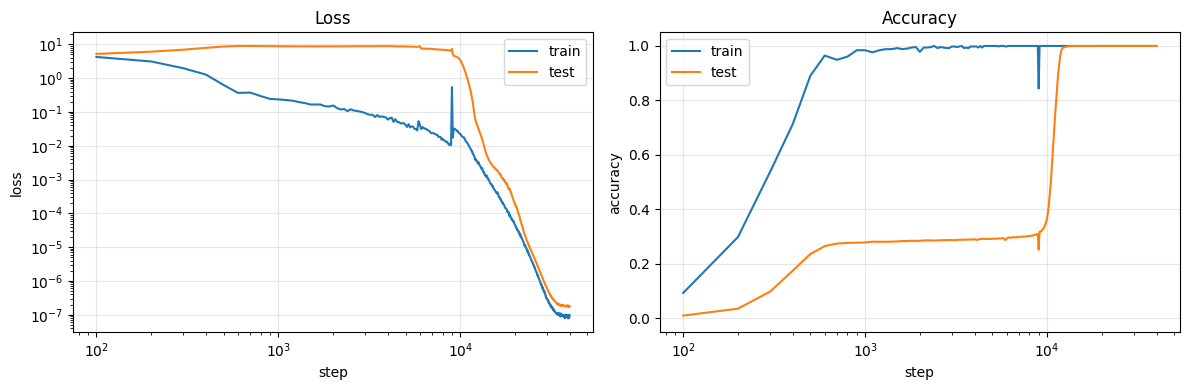

In [48]:
import matplotlib.pyplot as plt

if ckpt is not None and "history" in ckpt:
    h = ckpt["history"]
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

    ax_loss.plot(h["step"], h["train_loss"], label="train")
    ax_loss.plot(h["step"], h["test_loss"], label="test")
    ax_loss.set_xscale("log"); ax_loss.set_yscale("log")
    ax_loss.set_xlabel("step"); ax_loss.set_ylabel("loss")
    ax_loss.set_title("Loss"); ax_loss.legend(); ax_loss.grid(True, alpha=0.3)

    ax_acc.plot(h["step"], h["train_acc"], label="train")
    ax_acc.plot(h["step"], h["test_acc"], label="test")
    ax_acc.set_xscale("log")
    ax_acc.set_xlabel("step"); ax_acc.set_ylabel("accuracy")
    ax_acc.set_title("Accuracy"); ax_acc.set_ylim(-0.05, 1.05)
    ax_acc.legend(); ax_acc.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

## MLP neuron activations over (a, b)

Hook the post-ReLU activations of the MLP hidden layer at the `=` position, evaluated on every input pair `(a, b)` with `a, b ∈ [0, p)`. Each neuron then becomes a `p × p` image — one scalar per input pair.

In [49]:
import numpy as np

prime = 113

# All (a, b) pairs as input sequences [a, b, =]
pairs = torch.tensor(
    [[a, b, prime] for a in range(prime) for b in range(prime)],
    dtype=torch.long, device=device,
)

# Capture post-ReLU MLP activations via a forward hook on model.mlp.act
captured = {}
def _hook(_module, _inp, out):
    captured["acts"] = out.detach()

handle = model.mlp.act.register_forward_hook(_hook)
try:
    with torch.no_grad():
        model(pairs)
finally:
    handle.remove()

# captured["acts"]: [batch, n_ctx=3, d_mlp]; we want the "=" position (index 2)
acts = captured["acts"][:, 2, :].cpu().numpy()           # [p*p, d_mlp]
acts = acts.reshape(prime, prime, -1)                    # [a, b, neuron]
print(f"activations shape: {acts.shape}  (a, b, neuron)")

activations shape: (113, 113, 512)  (a, b, neuron)


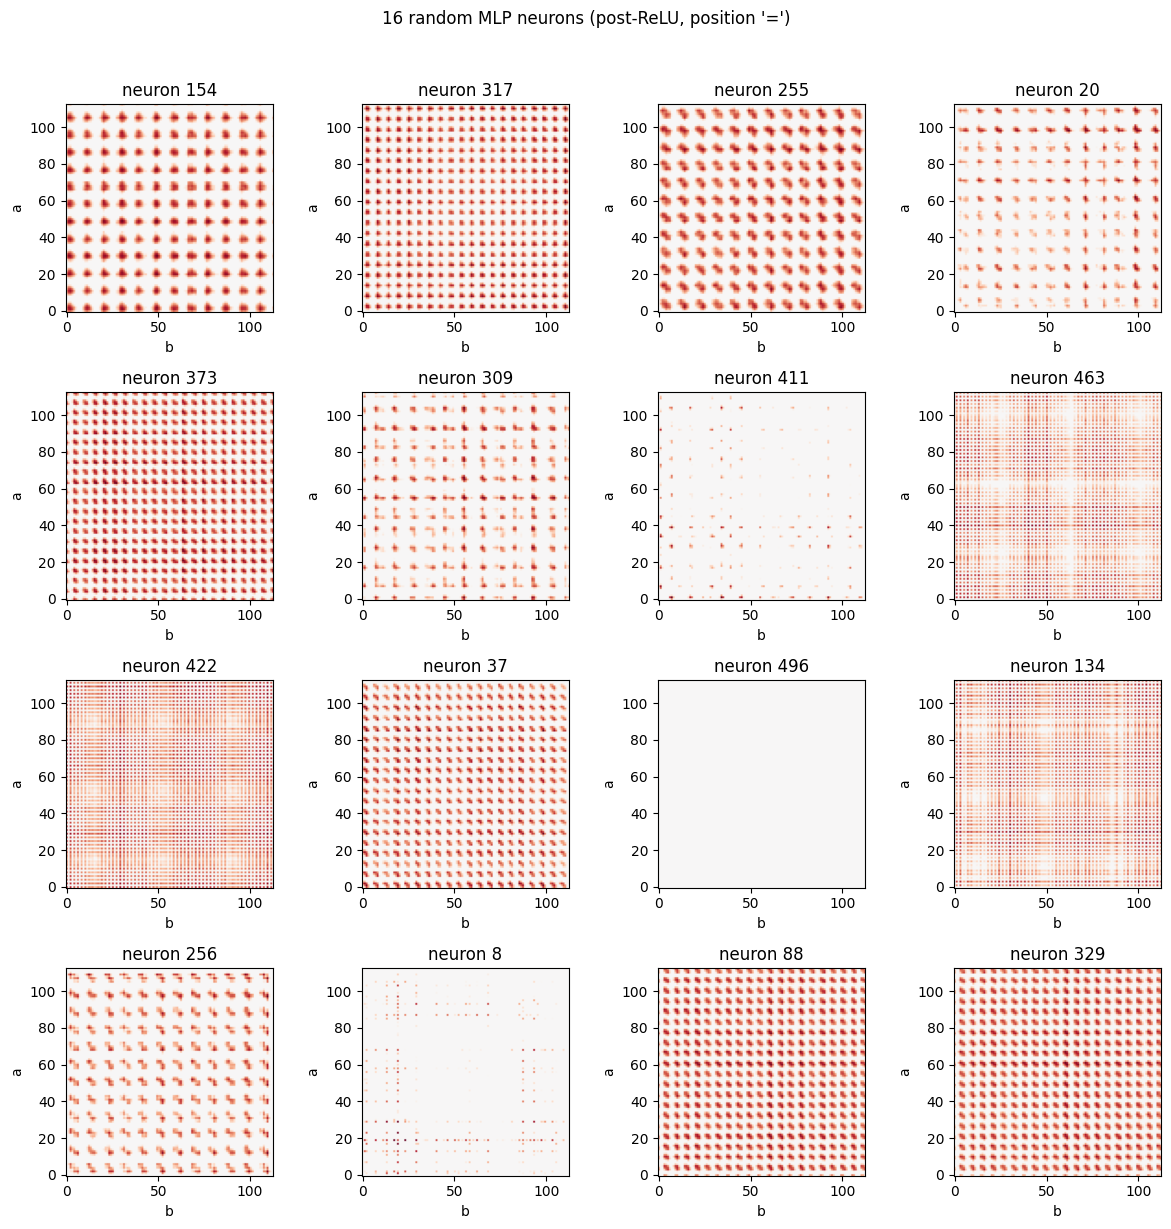

In [50]:
# Plot a random selection of neurons.
n_show = 16
rng = np.random.default_rng(0)
selected = rng.choice(acts.shape[-1], size=n_show, replace=False)

cols = 4
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for ax, neuron in zip(axes.flat, selected):
    a_max = max(abs(acts[:, :, neuron]).max(), 1e-9)
    ax.imshow(acts[:, :, neuron], origin="lower", cmap="RdBu_r",
              vmin=-a_max, vmax=a_max)
    ax.set_title(f"neuron {neuron}")
    ax.set_xlabel("b"); ax.set_ylabel("a")
for ax in axes.flat[n_show:]:
    ax.axis("off")
fig.suptitle(f"{n_show} random MLP neurons (post-ReLU, position '=')", y=1.02)
plt.tight_layout(); plt.show()

### 2D Fourier spectra

If a neuron's activation is approximately `f(a, b) ≈ g(cos(2πk·a/p), cos(2πk·b/p), …)` for a single frequency `k`, its 2D FFT will concentrate energy at a few `(k_a, k_b)` peaks. For modular addition we expect the peaks to lie on `k_a = ±k_b` (the lines that depend only on `a+b`).

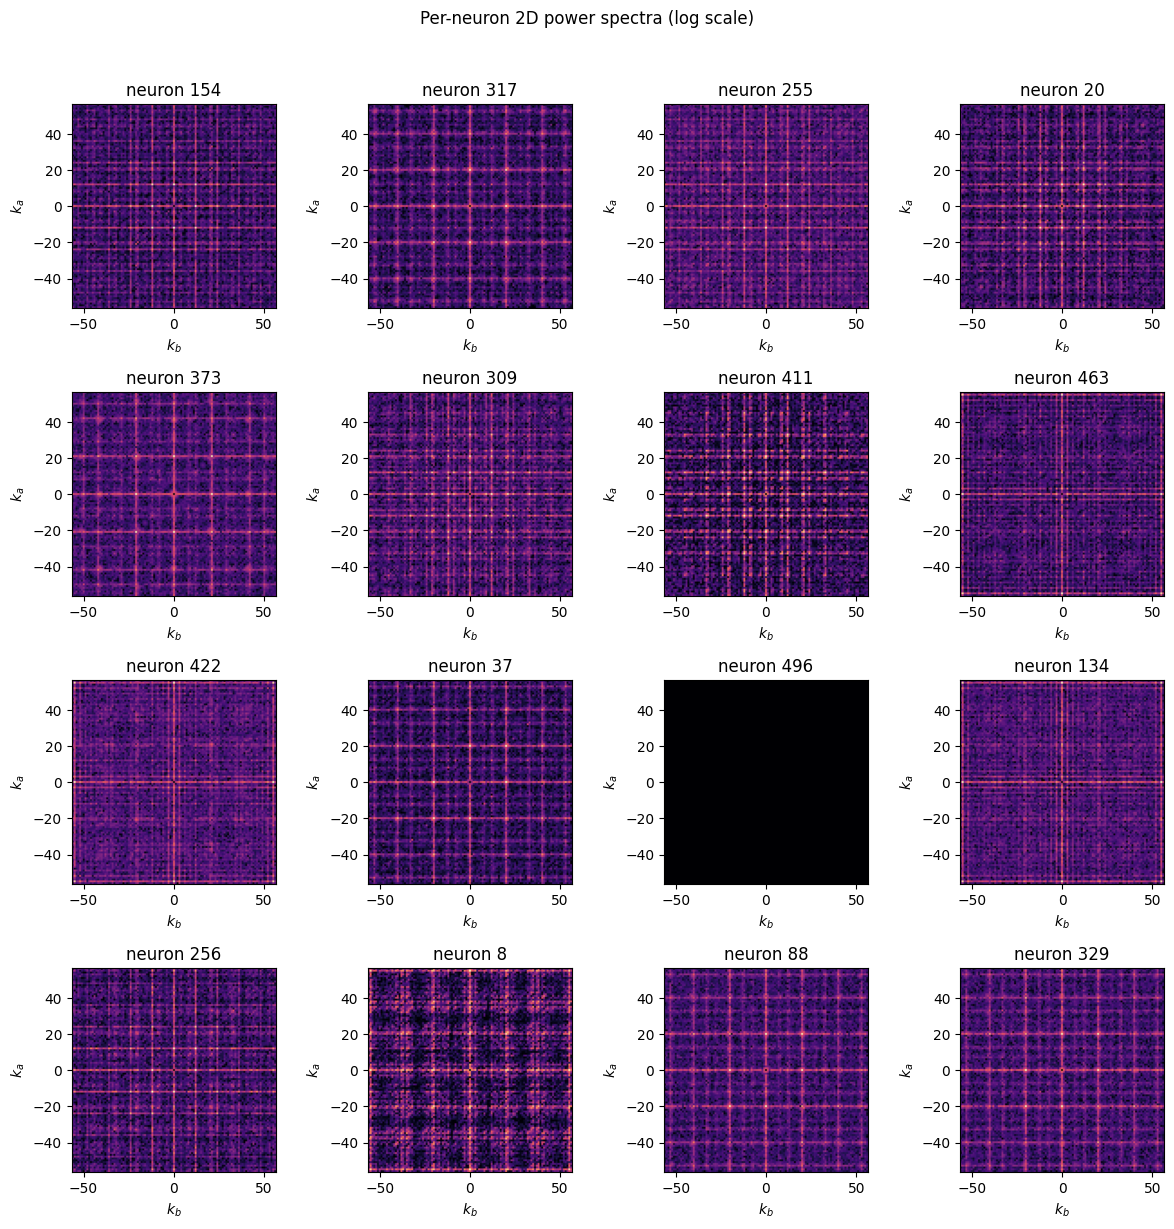

In [51]:
# 2D power spectrum of each neuron, mean-subtracted so the DC term doesn't dominate.
acts_centered = acts - acts.mean(axis=(0, 1), keepdims=True)
spec = np.fft.fftshift(np.fft.fft2(acts_centered, axes=(0, 1)), axes=(0, 1))
power = np.abs(spec) ** 2                                # [a-freq, b-freq, neuron]

freq = np.fft.fftshift(np.fft.fftfreq(prime, d=1.0)) * prime   # integer k, -p/2 .. p/2
extent = [freq[0] - 0.5, freq[-1] + 0.5, freq[0] - 0.5, freq[-1] + 0.5]

cols = 4
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for ax, neuron in zip(axes.flat, selected):
    p = power[:, :, neuron]
    ax.imshow(np.log1p(p), origin="lower", extent=extent, cmap="magma")
    ax.set_title(f"neuron {neuron}")
    ax.set_xlabel("$k_b$"); ax.set_ylabel("$k_a$")
for ax in axes.flat[n_show:]:
    ax.axis("off")
fig.suptitle("Per-neuron 2D power spectra (log scale)", y=1.02)
plt.tight_layout(); plt.show()

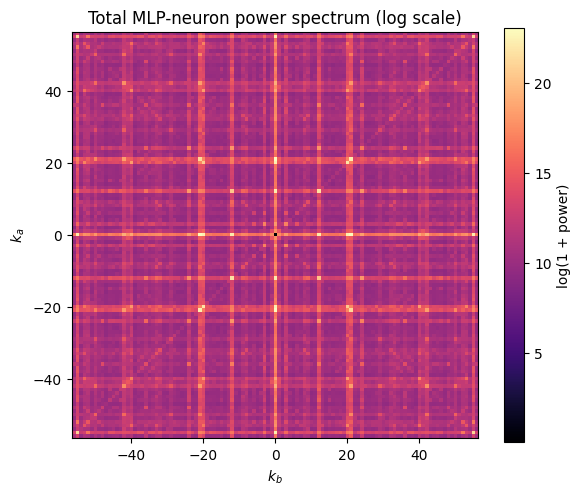

Top frequencies on k_a = k_b diagonal:
  k = +35   power = 4.86e+09
  k = -36   power = 4.86e+09
  k = -37   power = 3.34e+09
  k = +36   power = 3.34e+09
  k = -45   power = 2.63e+09
  k = +44   power = 2.63e+09
  k = +1   power = 1.33e+09
  k = -2   power = 1.33e+09


In [52]:
# Aggregate power across all neurons — this should reveal the k_a = ±k_b structure
# that's specific to functions of (a + b) mod p.
total_power = power.sum(axis=-1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(np.log1p(total_power), origin="lower", extent=extent, cmap="magma")
ax.set_xlabel("$k_b$"); ax.set_ylabel("$k_a$")
ax.set_title("Total MLP-neuron power spectrum (log scale)")
plt.colorbar(im, ax=ax, label="log(1 + power)")
plt.tight_layout(); plt.show()

# Which frequencies the network actually uses, ranked by total power on the k_a = +k_b diagonal:
diag = np.array([total_power[i, i] for i in range(prime)])           # unshifted indexing
diag_freqs = np.fft.fftfreq(prime, d=1.0) * prime
order = np.argsort(diag)[::-1]
print("Top frequencies on k_a = k_b diagonal:")
for i in order[:8]:
    k = int(round(diag_freqs[i]))
    if k == 0:
        continue
    print(f"  k = {k:+d}   power = {diag[i]:.3g}")

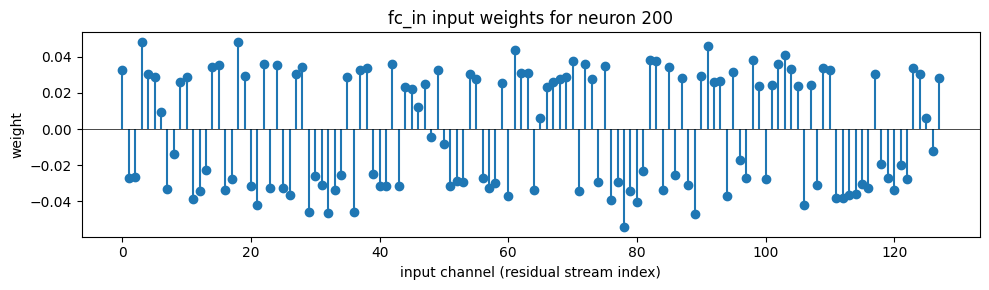

d_model = 128,  ‖w‖₂ = 0.361,  max|w| = 0.054


In [63]:
# Input weights of neuron 255 in fc_in: one weight per residual-stream channel.
neuron_id = 200
w = model.mlp.fc_in.weight[neuron_id].detach().cpu().numpy()   # shape [d_model]

fig, ax = plt.subplots(figsize=(10, 3))
ax.stem(np.arange(w.size), w, basefmt=" ")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("input channel (residual stream index)")
ax.set_ylabel("weight")
ax.set_title(f"fc_in input weights for neuron {neuron_id}")
plt.tight_layout(); plt.show()

print(f"d_model = {w.size},  ‖w‖₂ = {np.linalg.norm(w):.3f},  max|w| = {np.abs(w).max():.3f}")

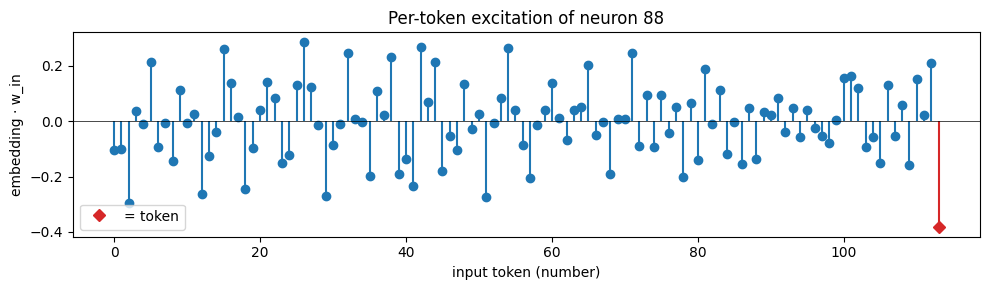

In [56]:
# Effective input weight per *token*: how much each vocab item excites neuron 255
# if its embedding lands in the MLP input (ignoring attention/pos-embedding mixing).
emb = model.embedding.weight.detach().cpu().numpy()       # [d_vocab, d_model]
per_token = emb @ w                                       # [d_vocab]

token_ids = np.arange(per_token.size)
fig, ax = plt.subplots(figsize=(10, 3))
ax.stem(token_ids[:prime], per_token[:prime], basefmt=" ", linefmt="C0-", markerfmt="C0o")
# the "=" token sits at index `prime`
ax.stem([prime], [per_token[prime]], basefmt=" ", linefmt="C3-", markerfmt="C3D",
        label="= token")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("input token (number)")
ax.set_ylabel("embedding · w_in")
ax.set_title(f"Per-token excitation of neuron {neuron_id}")
ax.legend()
plt.tight_layout(); plt.show()